In [1]:
import pandas as pd
print("pandas version:", pd.__version__)
# Loads in pandas

trips = pd.read_csv("trips_2026_h1.csv")
stations = pd.read_excel("stations_2026.xlsx")
# Assigns trips and stations

pandas version: 3.0.3


In [2]:
# PART A

print(f"Shape of trips is {trips.shape}")
print(f"Shape of stations is {stations.shape}")
print(len(trips))
print(len(stations))
    # Returns size of each file
    # Nothing unexpected found
        # ROW AUDIT: 137341 rows in trips, 25 rows in stations

print(trips.head(5))
print(trips.tail(5))
print(trips.sample(5))
print(stations.head(5))
print(stations.tail(5))
print(stations.sample(5))
    # Returns first 5 rows, last 5 rows, and a random 5 rows of each file
    # Nothing unexpected found; tail indicates that the last recorded trips are on 6/30

print(trips.info())
print(trips.dtypes)
print(stations.info())
print(stations.dtypes)
    # Returns the columns, types, non-null counts, memory usage (.info()) and data types (.dtypes) of each file
    # Found that all data in trips is strings
trips["start_time"] = pd.to_datetime(trips["start_time"])
trips["end_time"] = pd.to_datetime(trips["end_time"])
print(trips.dtypes)
print(trips.value_counts())
    # Converted start_time and end_time in trips to datetime so that operations can be completed on them

print(trips.isna().sum())
print(stations.isna().sum())
    # Returns sum of the null values of each column in each file
    # In trips, end_time has 804 null and end_station_id has 3999 null
print((trips["end_time"].isna() & trips["end_station_id"].isna()).value_counts())
    # Returns the number of trips that are null in end_time that are also null in end_station
    # Found that only 19 trips are missing both an end_time and end_station_id, indicating that missingness in the two is likely independent
trips["no_end_time"] = trips["end_time"].isna()
trips["end_station_id"] = trips["end_station_id"].fillna("unknown")
print(trips.isna().sum())
print(stations.isna().sum())
    # Decided to fill trips with no end_station_id, as they may be indicative of a real phenomenon but will not affect numerical analysis because the dtype is string
    # Decided to keep and flag trips with no end_time, as they may be indiciative of a real phenomenon but must be able to be filtered out to complete numerical analysis

print(trips.duplicated().sum())
print(stations.duplicated().sum())
    # Returns number of duplicated rows in each file
    # Found 350 duplicates in trips, no duplicates in stations
trips = trips.drop_duplicates()
print(trips.duplicated().sum())
    # Dropped 350 duplicates in trips -- Exact duplicates were errors
print(len(trips))
print(len(stations))
    # Returns the number of values of each column
        # ROW AUDIT: 136191 rows in trips, 25 rows in stations



print(trips.describe())
print(stations.describe())
    # Returns the count, unique, most frequent, and frequency of most frequent values; data will need to be in numerical type to be useful for analysis
    # Found that trips needs to have a duration column to be analyzed numerically; there are 5 unique rider_types and 50 unique start_station_names, indicating that the data needs to be cleaned
trips["duration_min"] = (
   (trips["end_time"] - trips["start_time"]).dt.total_seconds() / 60
)
print(trips.describe())
    # Returns .describe() of trips with a column including the duration of a trip
    # Found that there are improbable and impossible durations (-92.617 and 4,784.733 are not times in minutes that make sense for this data)
print((trips["duration_min"] <= 0).sum())
print(((trips["duration_min"] > 60*12)).sum())
    # Returns number of trips that are negative or over 12 hours long
    # Found 180 trips that are negative and 240 trips that are over 12 hours long
print(trips["rider_type"].value_counts())
print(trips["start_station_name"].value_counts())
    # Returns count of each rider_type and start_station_name
    # Verifies that original data should be clean; rider_type has some values with inconsistent capitalization and start_station_name has some values with inconsistent spacing and capitalization
trips["rider_type"] = (
    trips["rider_type"]
        .str.strip()
        .str.title()
        .str.replace("Day_Pass", "Day Pass")
)
trips["start_station_clean"] = (
    trips["start_station_name"]
    .str.strip()
    .str.title()
    .str.replace("Cumberland Ave & 17Th St", "Cumberland Ave & 17th St")
    .str.replace("Student Union - Ut", "Student Union - UT")
    .str.replace("World'S Fair Park", "World's Fair Park")
    .str.replace("Cumberland Ave & 22Nd St", "Cumberland Ave & 22nd St")
)
print(trips["rider_type"].value_counts())
print(trips["start_station_clean"].value_counts())
    # Returns rider_type and start_station_name after stripping and title-casing
    # Verifies that data is consistent and usable
print(len(trips))
print(len(stations))
        # ROW AUDIT: 136191 rows in trips, 25 rows in stations
trips_possible = trips[
    (trips["duration_min"] > 0) &
    (trips["duration_min"] < 60 * 12)
]
print(trips_possible.describe())
    # Creates a filtered trips_possible that is trips that are under 12 hours and over 0 minutes
    # Found that trips_possible has a right skew

Shape of trips is (137341, 8)
Shape of stations is (25, 7)
137341
25
    trip_id           start_time             end_time start_station_id  \
0  T0418495  2026-01-01 00:27:32  2026-01-01 00:35:34              S05   
1  T0316555  2026-01-01 01:00:29  2026-01-01 01:20:59              S05   
2  T0388966  2026-01-01 01:08:12  2026-01-01 01:17:50              S22   
3  T0313803  2026-01-01 01:21:39  2026-01-01 01:47:57              S21   
4  T0425615  2026-01-01 01:51:41  2026-01-01 02:08:42              S02   

       start_station_name end_station_id rider_type bike_type  
0       World's Fair Park            S04     casual  electric  
1       World's Fair Park            S11     casual   classic  
2              Tyson Park            S02     member  electric  
3            Caswell Park            S21     casual  electric  
4  Gay Street & Union Ave            S02     casual   classic  
         trip_id           start_time             end_time start_station_id  \
137336  T0320827  2026-

Choices:
- Converted start_time and end_time to times so that operations could be completed
- Ran .fillna() on  trips with no end_station_id, as they may be indicative of a real phenomenon but will not affect numerical analysis because the dtype is string
- Decided to keep and flag trips with no end_time, as they may be indiciative of a real phenomenon but must be able to be filtered out to complete numerical analysis
- Decided to drop trips that are exact duplicate rows, as these can safely be assumed to be errors that would otherwise impact the data analysis
- Created a filtered DataFrame for trips with negative duration or duration over 12 hours because these are "impossible" trips--a trip cannot be a negative duration, and trips over 12 hours are outliers and can be safely assumed to be caused by error, such as a rider forgetting to mark a ride as complete. Chose to filter instead of drop so that these impossible trips can be inspected

month            1       2        3        4        5        6
rider_type                                                    
Casual      3455.0  4277.0   6729.0   8940.0  10783.0  11402.0
Day Pass       NaN     NaN   1114.0   2248.0   3434.0   4145.0
Member      6767.0  8383.0  12397.0  15440.0  18077.0  19400.0


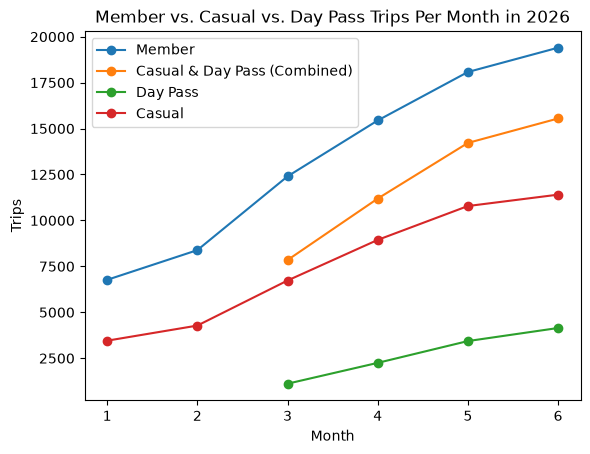

In [3]:
# PART B
trips["month"] = trips["start_time"].dt.month
riders_by_month = trips.groupby(["rider_type", "month"]).size().unstack()
print(riders_by_month)
    # Creates a table count of trips by rider type for each month

import matplotlib.pyplot as plt

plt.plot(riders_by_month.columns, riders_by_month.loc["Member"], label="Member", marker="o")
plt.plot(riders_by_month.columns, riders_by_month.loc["Casual"] + riders_by_month.loc["Day Pass"], label="Casual & Day Pass (Combined)", marker="o")
plt.plot(riders_by_month.columns, riders_by_month.loc["Day Pass"], label="Day Pass", marker="o")
plt.plot(riders_by_month.columns, riders_by_month.loc["Casual"], label="Casual", marker="o")
plt.title("Member vs. Casual vs. Day Pass Trips Per Month in 2026")
plt.xlabel("Month"); plt.ylabel("Trips"); plt.legend()
plt.savefig("monthly_by_rider_type.png", dpi=150, bbox_inches="tight")
plt.show()
    # Plots count of Member, Non-Member (Casual and Day Pass combined), Day Pass, and Casual trips in 2026 by month

The number of trips taken by non-member riders is alleviated by the creation of a day pass. For January and February, prior to the implementation of the day pass, the ridership of casual riders was down 1,244 trips and 1,389 trips compared to 2025, respectively. Without the day pass, the casual ridership for March, April, May, and June was down 1,840, 2,301, 2,424, and 2,414 trips respectively from 2025, for an average of 1,935 fewer trips for casual riders per month of 2026 compared to the same period in 2025. However, the day pass, which was created to increase ridership of otherwise casual riders, can be counted along with casual riders to get a total number of trips that were non-member trips. Including these trips, ridership between March and July had changes of -726, -53, +1,010, and +1,731 trips, respectively, from their counterparts in 2025, for an average of 490 more rides per month for non-members compared to the same period. This evidence would suggest that the day pass implementation alleviates the gap in ridership driven by the drop in casual ridership.

               station_name     neighborhood  docks  arrivals_count  \
17      Sequoyah Hills Park   Sequoyah Hills     10             986   
3              Caswell Park   East Knoxville     10            1505   
1   Bearden - Kingston Pike          Bearden     12            2245   
24            Zoo Knoxville   East Knoxville     10            1971   
20     Suttree Landing Park  South Knoxville     10            2064   

    arrivals_per_dock  
17          98.600000  
3          150.500000  
1          187.083333  
24         197.100000  
20         206.400000  
                station_name  neighborhood  docks  arrivals_count  \
15    Old City - Jackson Ave      Old City     16            7777   
8     Gay Street & Union Ave      Downtown     16            9030   
4   Cumberland Ave & 17th St  Fort Sanders     16            9048   
21     The Hill - Ayres Hall     UT Campus     12            6930   
13             Market Square      Downtown     20           12487   

    arrivals_p

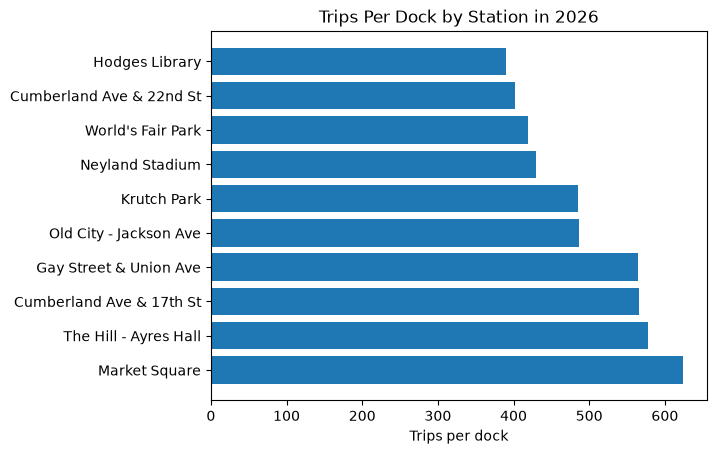

In [4]:
# PART C
merged = pd.merge(
    trips, stations,
    left_on="start_station_id", right_on="station_id",
    how="left",
)
assert len(merged) == len(trips)   # trust, but verify

per_station = (
    merged.groupby(["station_name", "neighborhood", "docks"]).size().reset_index(name="arrivals_count")
)
per_station["arrivals_per_dock"] = per_station["arrivals_count"] / per_station["docks"]
print(per_station.sort_values("arrivals_per_dock", ascending=True).head(5))
print(per_station.sort_values("arrivals_per_dock", ascending=True).tail(5))
    # Shows the 5 least- and 5 most-pressured stations

top = per_station.sort_values("arrivals_per_dock", ascending=False).head(10)
plt.barh(top["station_name"], top["arrivals_per_dock"])
plt.title("Trips Per Dock by Station in 2026")
plt.xlabel("Trips per dock")
plt.savefig("trips_per_dock_by_station.png", dpi=150, bbox_inches="tight")
plt.show()
    # Creates horizontal bar chart of the 10 most-pressured stations, busiest at top

The expansion of docks in the Student Union and Hodges stations relieved pressure, moving them significantly lower than they previously were (Hodges is now the tenth most-pressured station, down from being the fourth, and the Student Union is no longer within the top ten, down from being the fifth).
Bearden and Sequoyah Hill Park are both very low-pressure stations. However, Bearden lies generally around the other low-performing stations, having 24.7% more arrivals per dock in 2026 than Caswell Park, which has 150 arrivals per dock, and only 5.1% fewer arrivals per dock in 2026 than Zoo Knoxville, which has 197 arrivals per dock; because of this, it should continue to be watched, as it is low-performing, but generally within the average. Sequoyah Hills Park, on the other hand, is only 65.3% of the total ridership of the second-least-pressured station, which has 150 arrivals per dock. Because of this, this station should be relocated.
The new station S25, Cumberland Ave & 22nd St, is within the top ten most pressured stations, indicating that it is being frequently used. It can be assumed that the implementation of this station has encouraged riders that would otherwise attend more pressured stations to attend it instead, decreasing pressure.

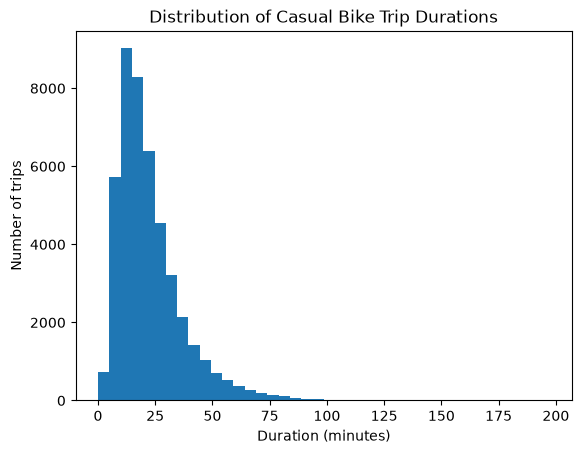

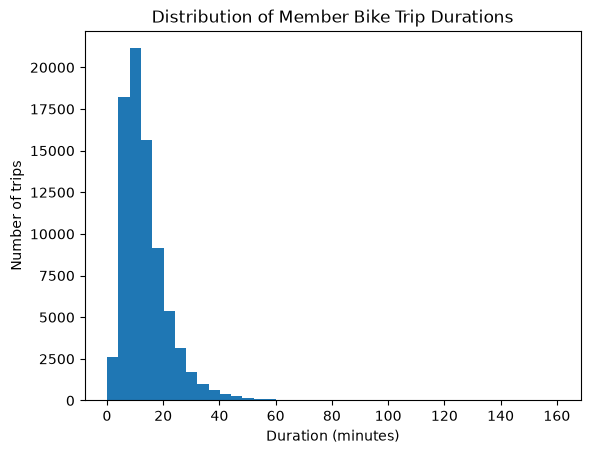

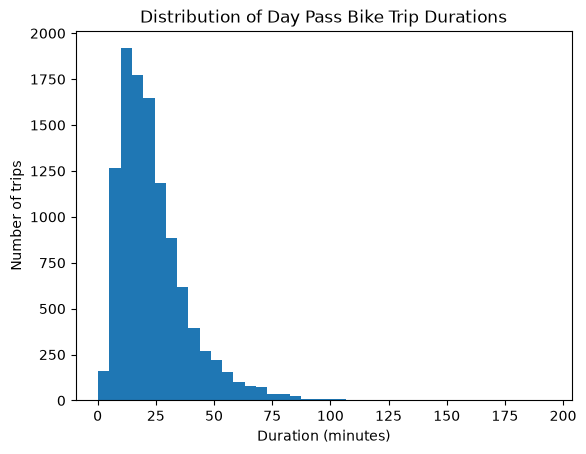

In [5]:
# PART D
trips_casual = trips_possible[(trips_possible["rider_type"] == "Casual")]
trips_member = trips_possible[(trips_possible["rider_type"] == "Member")]
trips_day_pass = trips_possible[(trips_possible["rider_type"] == "Day Pass")]
    # Creates DataFrames of possible trips from the different rider types
plt.hist(trips_casual["duration_min"], bins=40)
plt.title("Distribution of Casual Bike Trip Durations")
plt.xlabel("Duration (minutes)"); plt.ylabel("Number of trips")
plt.savefig("distribution_of_casual_bike_trip_durations.png", dpi=150, bbox_inches="tight")
plt.show()
plt.hist(trips_member["duration_min"], bins=40)
plt.title("Distribution of Member Bike Trip Durations")
plt.xlabel("Duration (minutes)"); plt.ylabel("Number of trips")
plt.savefig("distribution_of_member_bike_trip_durations.png", dpi=150, bbox_inches="tight")
plt.show()
plt.hist(trips_day_pass["duration_min"], bins=40)
plt.title("Distribution of Day Pass Bike Trip Durations")
plt.xlabel("Duration (minutes)"); plt.ylabel("Number of trips")
plt.savefig("distribution_of_day_pass_bike_trip_durations.png", dpi=150, bbox_inches="tight")
plt.show()
    # Creates histograms showing the distribution of trip durations of different rider types

Day pass riders behave most like casual riders; the distribution of the duration of their trips is concentrated around 25 minutes, which is congruent with casual ridership and unlike member ridership, which is concentrated at less than 20 minutes. This indicates that the average day pass rider is more similar to the behaviors of a casual rider rather than a member rider.

# PART E: MEMO
The implementation of the day pass and creation of new stations have improved ridership from and decreased bottlenecking of stations in 2025.
Casual riders took an average of 1,935 fewer trips per month in 2026 compared to the same period in 2025. However, non-member riders (casual and day pass riders combined), took an average of 490 more rides per month compared to the same period in 2025 (see chart:"Member vs. Casual vs. Day Pass Trips Per Month in 2026"). Additionally, the Student Union and Hodges stations are relatively significantly less pressured than they previously were (Hodges is now the tenth most-pressured station, down from being the fourth, and the Student Union is no longer within the top ten, down from being the fifth). The new station S25, Cumberland Ave & 22nd St, is within the top ten most pressured stations.
The day pass riders exhibited similar behavior as casual riders in their duration of their trips, indicating that these riders were the same consumer type as casual riders, which suggests that these riders would not otherwise be members. It can be assumed that the dock expansion has relieved pressure in the stations and that the implementation of the new station has encouraged riders that would otherwise attend more pressured stations to attend it instead, decreasing pressure. This is our interpretation, not a proven cause.
This evidence is observational. There was also a steep drop-off in July 2025 that has not proven to not be seasonality because the 2026 data is only through June. Additionally, there are only four months of data for the day pass: we cannot be certain that the newness of it is not inflating ridership.
Recommendations: Continue the day pass promotion through the end of the year to compare ridership data to 2025.

REFLECTION
The decision that would most change my conclusion is if I were to not count day pass holders and casual members together as non-members and instead determined that the day pass is cannibalizing member riders. If I decided this was accurate, then the average ridership of casual riders would be down by a substantial amount (an average of 1,935 trips per month), and it would be assumed that these riders that are counted as "adding" to the total ridership of Ride Knox would instead be riders that would pay for a membership but are choosing to buy a cheaper option instead; this would mean that not only is casual ridership down, but the day pass is also decreasing member ridership. I chose not to accept this decision because the behavior of the day pass riders is most similar to the casual riders in that they take longer trips on average than member riders.

AI DISCLOSURE
I used a generative AI tool during section A to explain how to use Boolean masks so that I could determine if trips with no end_station_id and no end_time were correlated. Also in section A, I used generative AI to troubleshoot my syntax – I was getting an error that it noted that was because I made trips into a list instead of a DataFrame. I also used it in part D to troubleshoot, because I was getting a blank graph when trying to plot my trips_possible–this is because I accidentally created the DataFrame before cleaning the data. All final answers and interpretations are my own.